In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


In [26]:
plt.style.use('/home/joliveira/Documents/franck-hertz/joao.mplstyle')
# --- DEFINIÇÃO DO TEMA GLOBAL USANDO rcParams ---
plt.rcParams['figure.figsize'] = (20, 12) # Define o tamanho da figura para 10x6 polegadas
plt.rcParams['font.size'] = 14           # Define o tamanho da fonte geral como 14
plt.rcParams['axes.titlesize'] = 25      # Tamanho da fonte do título
plt.rcParams['axes.labelsize'] = 20      # Tamanho da fonte dos rótulos dos eixos
plt.rcParams['axes.grid'] = True        # Habilita/desabilita a grade em todos os gráficos
plt.rcParams['grid.linestyle'] = '-'      # Estilo da grade: tracejado
plt.rcParams['grid.alpha'] = 0.6         # Transparência da grade
plt.rcParams['grid.linewidth'] = 0.8
plt.rcParams['savefig.dpi'] = 700        # Alta resolução para salvar as figuras
plt.rcParams['lines.linestyle'] = '-'    # Linha sólida
plt.rcParams['lines.linewidth'] = 2.5   # Espessura da linha
plt.rcParams['figure.facecolor'] = 'none'   # Fundo da figura transparente
plt.rcParams['axes.facecolor']   = 'none'   # Fundo dos eixos transparente
plt.rcParams['savefig.facecolor'] = 'none'  # Ao salvar, mantém transparente
plt.rcParams['savefig.transparent'] = True  # Salva figuras com fundo transparente
plt.rcParams['xtick.labelsize'] = 16    # Tamanho dos rótulos do eixo x
plt.rcParams['ytick.labelsize'] = 16    # Tamanho dos rótulos do eixo y
# ---------------------------------------------------

Missing colon in file '/home/joliveira/Documents/franck-hertz/joao.mplstyle', line 617 ('view raw')
Missing colon in file '/home/joliveira/Documents/franck-hertz/joao.mplstyle', line 618 ('matplotlibrc hosted with ❤ by GitHub')


# Aqui eu criei um código que encontra os vales para cada dado experimental obtido

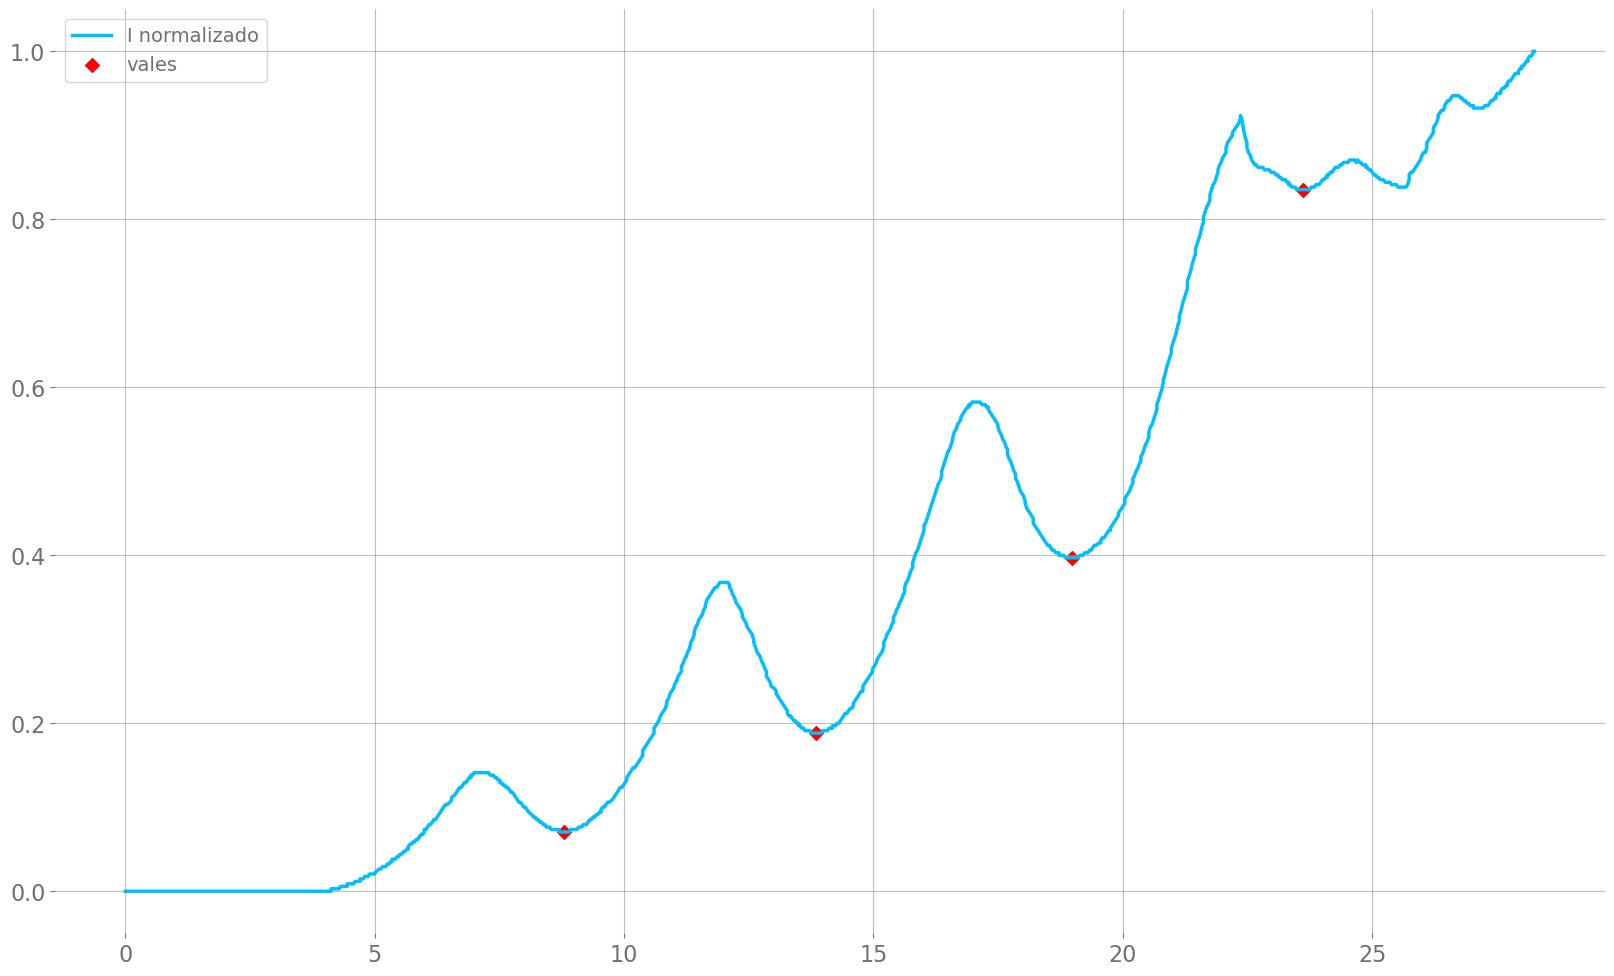

5.058539999999999
5.12298
4.639680000000002


In [27]:
caminho = "Dados experimentais 23.10.2025 (Com fator de escala)/m1-m-e-T_150.txt"
df = pd.read_csv(caminho,sep=r'\s+',header=None,names=['V','I'])
I = df['I'].to_numpy()
V = df['V'].to_numpy()

I_max = df['I'].max()
I_min = df['I'].min()
I = (I-I_min)/(I_max-I_min)
# Encontrar picos e vales
peaks, _ = find_peaks(I, distance=100, prominence=0.2)
vales, _ = find_peaks(-I, distance=100, prominence=0.05)

# Filtrar vales com V < 4.9
vales = vales[V[vales] >= 4.9]

# Plot
plt.plot(V, I, label="I normalizado")
# plt.scatter(V[peaks], I[peaks], marker="^", color="green", label="picos")
plt.scatter(V[vales], I[vales], marker="D", color="red", label="vales")
plt.legend()
plt.show()

for i in range(len(vales)-1):
  print(V[vales[i+1]]-V[vales[i]])

# Aqui eu vou começar a fazer os plots para uma temperatura específica

### Variando V1

,Medida,V1 [Volts],V2 [Volts],V4 [Volts],Escala
0,1,6.09,6.19,0.5,1.000000e-07
1,2,5.63,6.19,0.5,1.000000e-07
2,3,5.01,6.19,0.5,1.000000e-08
3,4,4.61,6.19,0.5,1.000000e-09
4,5,6.09,6.19,0.5,1.000000e-07


Mínimo global: 0.000000000, Máximo global: 0.000034000


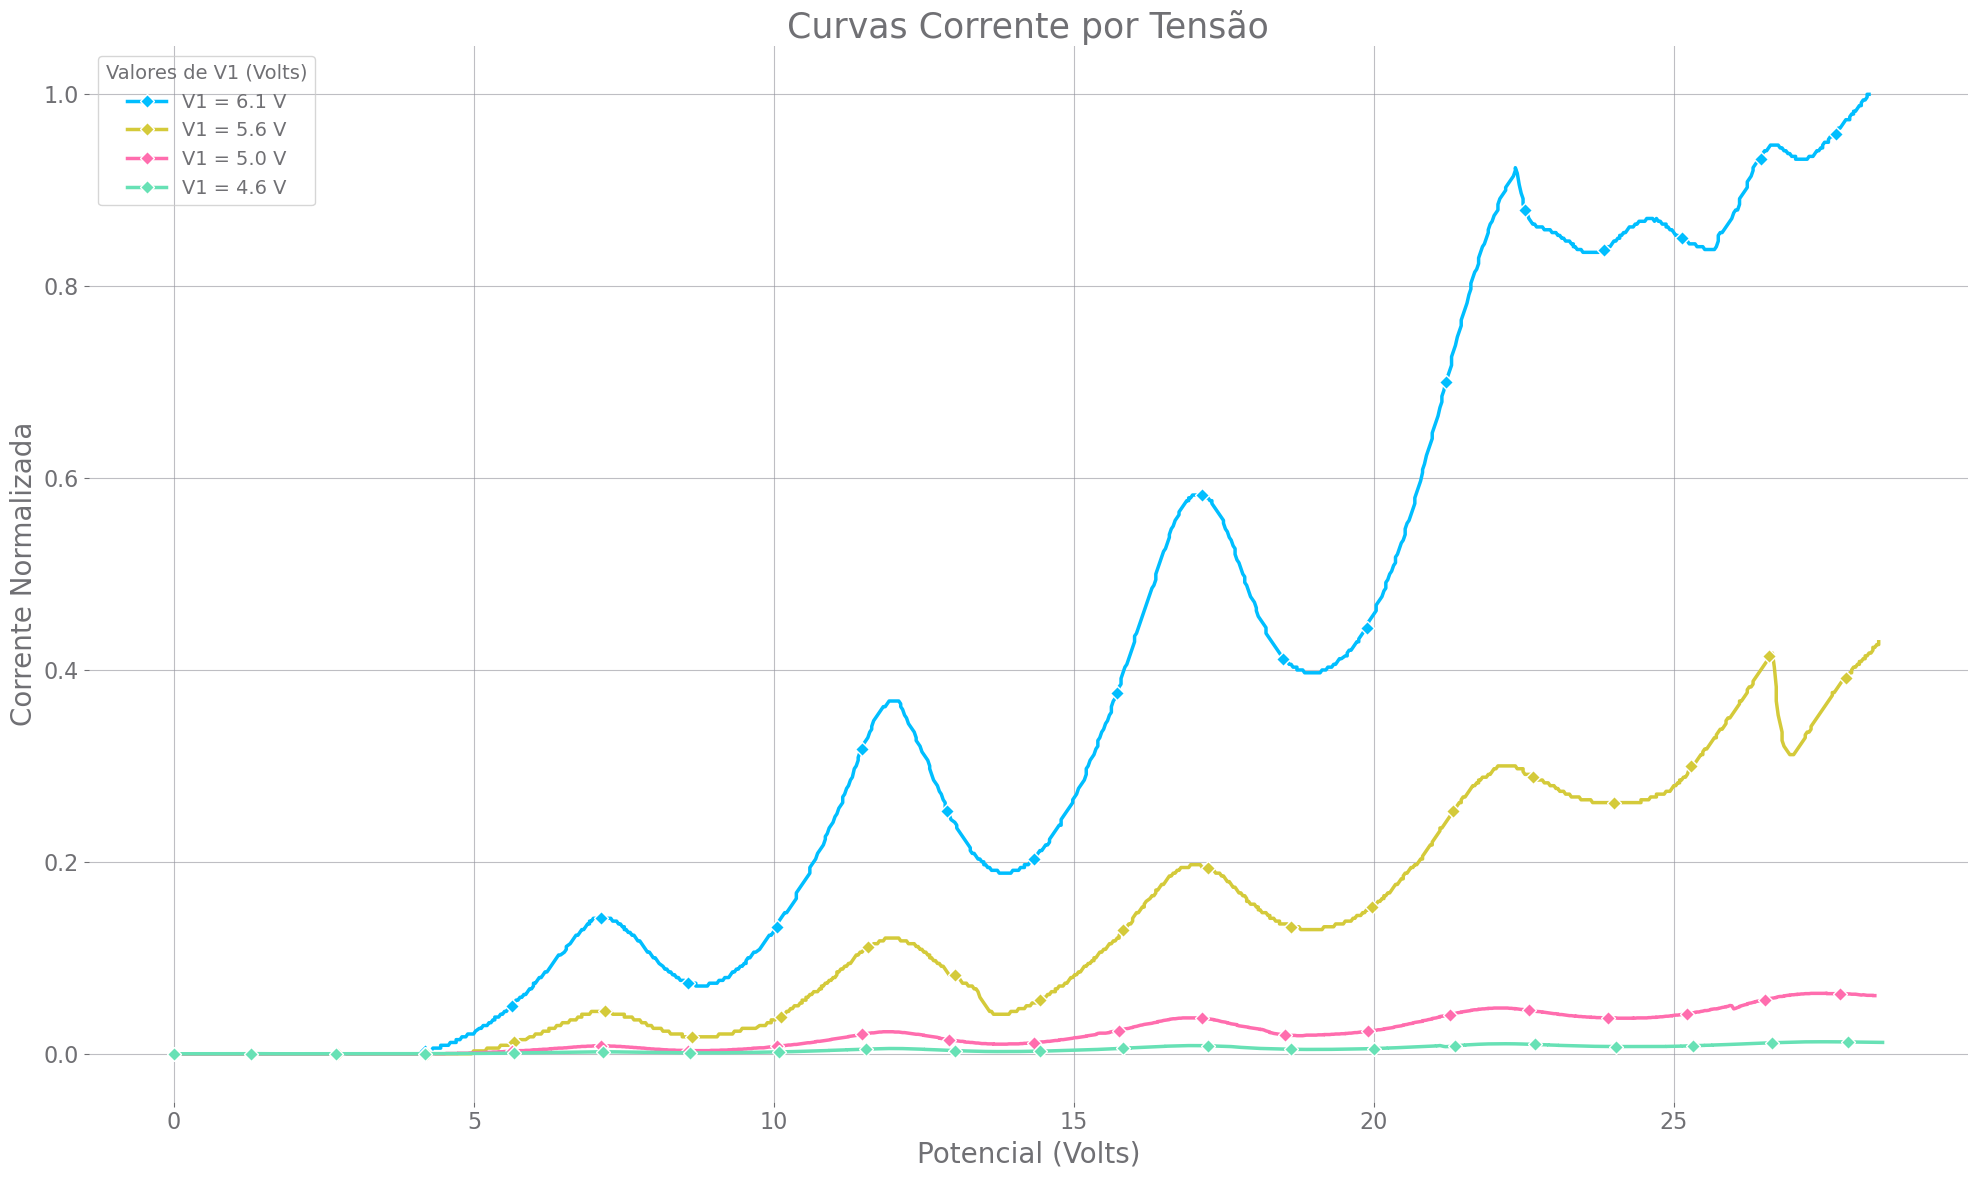

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# Caminhos fornecidos
caminho_v1 = "Medidas Multiplas Excitações 150°C (Com fator de escala).xlsx"
caminho_v1_dados = "Dados experimentais 23.10.2025 (Com fator de escala)/"

# Lê o arquivo principal (com fatores de escala)
df_v1 = pd.read_excel(caminho_v1)
display(df_v1.head())

# Limite de potencial
limite_potencial = 30

# Lista para armazenar as medidas
dados_medidas = []

for medida in range(1, 5):
    nome_arquivo = f"m{medida}-m-e-T_150.txt"
    caminho_arquivo = os.path.join(caminho_v1_dados, nome_arquivo)

    # Lê o arquivo de dados
    df_dados = pd.read_csv(caminho_arquivo, sep=r"\s+", header=None, names=["Potencial (V)", "Corrente (uA)"])

    # Fator de escala e valor de V1
    linha_info = df_v1.loc[df_v1["Medida"] == medida]
    escala = linha_info["Escala "].values[0]
    v1_valor = linha_info["V1 [Volts]"].values[0]

    # Aplica o fator de escala
    df_dados["Corrente (uA)"] *= escala

    # Filtra até o limite de potencial
    df_dados = df_dados[df_dados["Potencial (V)"] <= limite_potencial].reset_index(drop=True)

    # Armazena a medida junto com o valor de V1
    dados_medidas.append((v1_valor, df_dados))

# Calcula min e max globais (correntes filtradas)
todas_correntes = np.concatenate([df["Corrente (uA)"].values for _, df in dados_medidas])
I_min, I_max = todas_correntes.min(), todas_correntes.max()

print(f"Mínimo global: {I_min:.9f}, Máximo global: {I_max:.9f}")

# Gráfico normalizado

for v1_valor, df_dados in dados_medidas:
    df_dados["Corrente Normalizada"] = (df_dados["Corrente (uA)"] - I_min) / (I_max - I_min)
    plt.plot(df_dados["Potencial (V)"], df_dados["Corrente Normalizada"], label=f"V1 = {v1_valor:.1f} V",marker="D",markevery=50)

# Configurações do gráfico
plt.xlabel("Potencial (Volts)")
plt.ylabel("Corrente Normalizada")
plt.title(f"Curvas Corrente por Tensão")
plt.legend(title="Valores de V1 (Volts)")
plt.grid(True)
plt.tight_layout()
plt.show()


### Variando V2

,Medida,V1 [Volts],V2 [Volts],V4 [Volts],Escala
0,1,6.09,6.19,0.5,1.000000e-07
1,2,5.63,6.19,0.5,1.000000e-07
2,3,5.01,6.19,0.5,1.000000e-08
3,4,4.61,6.19,0.5,1.000000e-09
4,5,6.09,6.19,0.5,1.000000e-07


Mínimo global: 0.000000000, Máximo global: 0.000033200


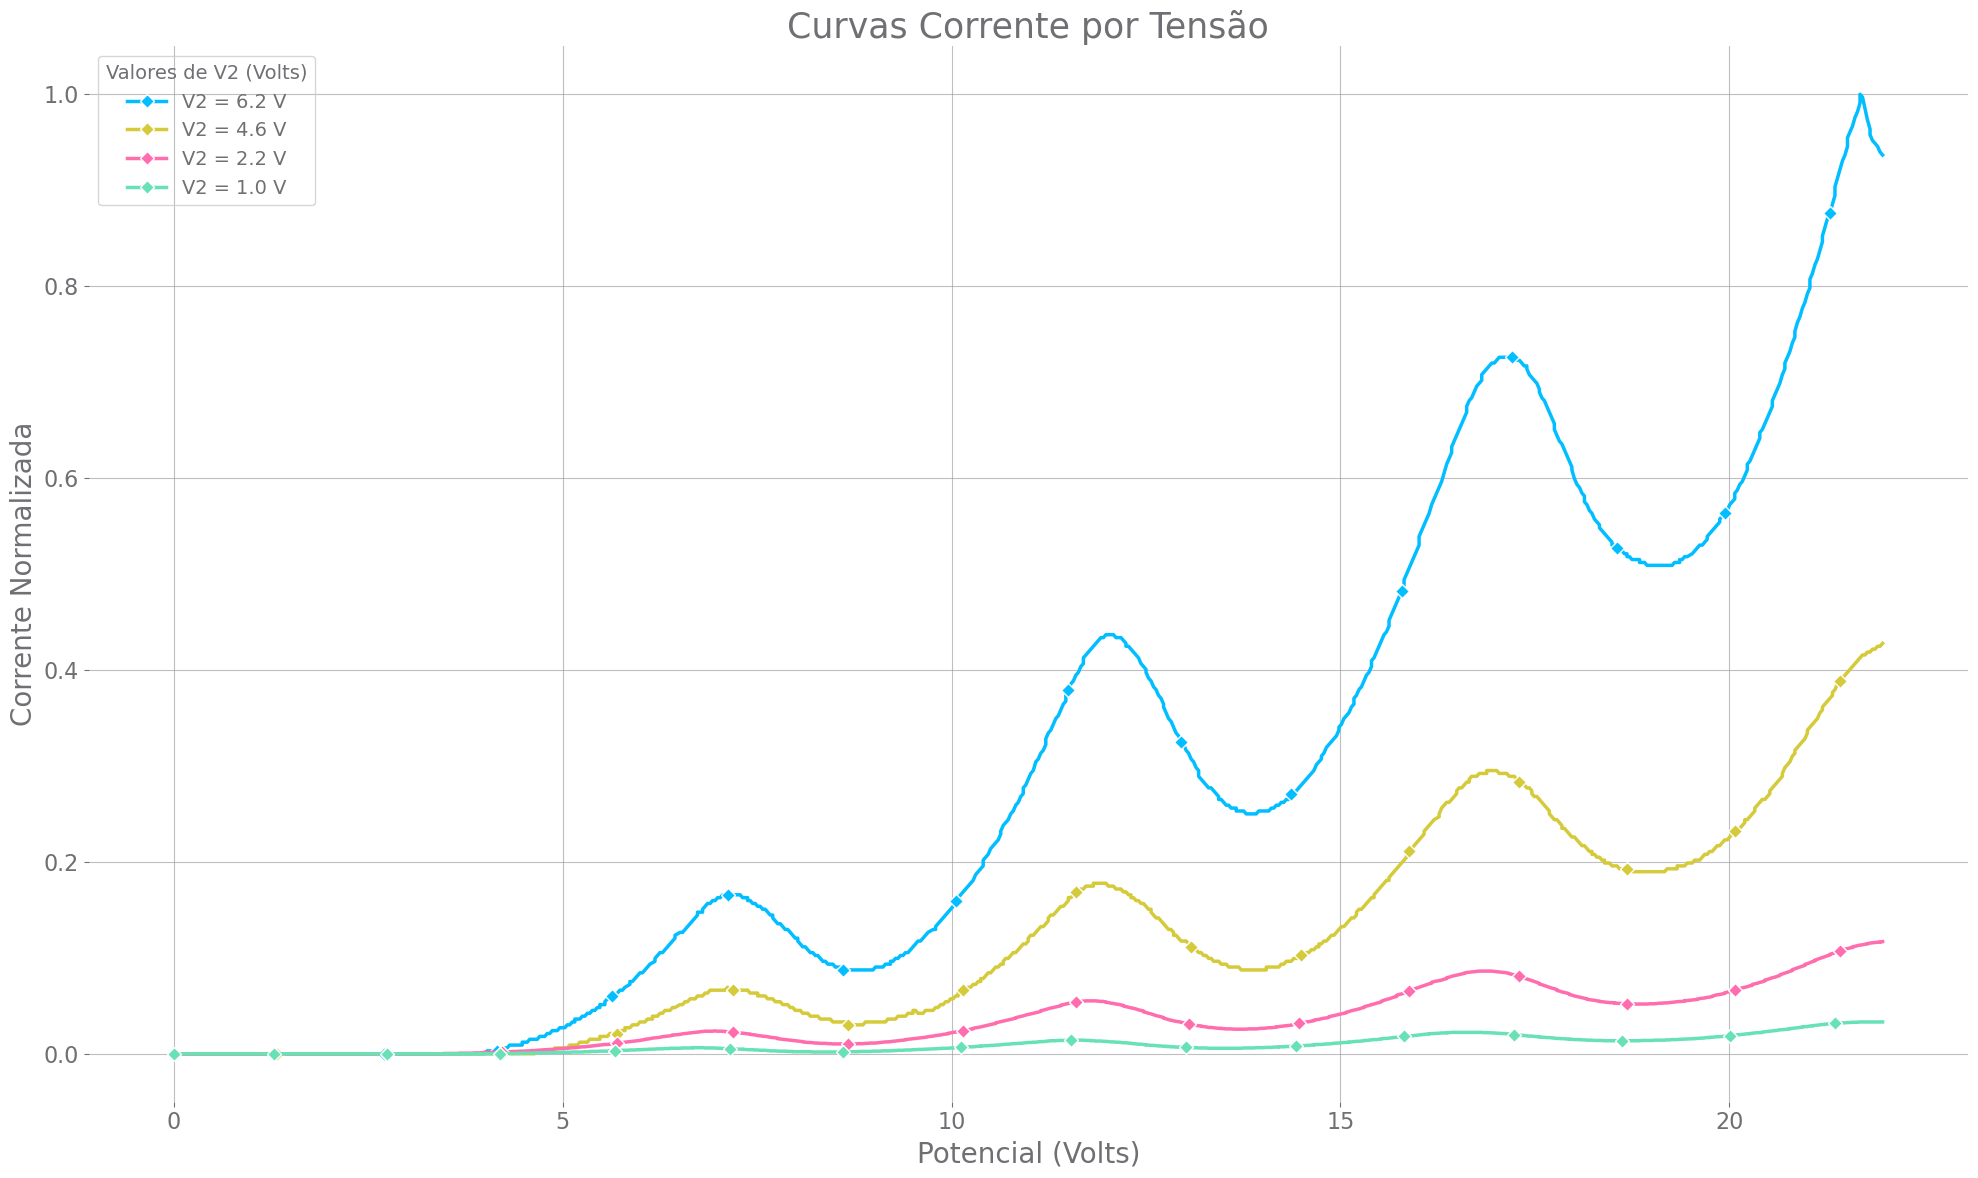

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# Caminhos fornecidos
caminho_v2 = "Medidas Multiplas Excitações 150°C (Com fator de escala).xlsx"
caminho_v2_dados = "Dados experimentais 23.10.2025 (Com fator de escala)/"

# Lê o arquivo principal (com fatores de escala)
df_v2 = pd.read_excel(caminho_v2)
display(df_v2.head())

# Limite de potencial
limite_potencial = 22

# Lista para armazenar as medidas
dados_medidas = []

for medida in range(5, 9):
    nome_arquivo = f"m{medida}-m-e-T_150.txt"
    caminho_arquivo = os.path.join(caminho_v2_dados, nome_arquivo)

    # Lê o arquivo de dados
    df_dados = pd.read_csv(
        caminho_arquivo,
        sep=r"\s+",
        header=None,
        names=["Potencial (V)", "Corrente (uA)"]
    )

    # Fator de escala e valor de V2
    linha_info = df_v2.loc[df_v2["Medida"] == medida]
    escala = linha_info["Escala "].values[0]
    v2_valor = linha_info["V2 [Volts]"].values[0]

    # Aplica o fator de escala
    df_dados["Corrente (uA)"] *= escala

    # Filtra até o limite de potencial
    df_dados = df_dados[df_dados["Potencial (V)"] <= limite_potencial].reset_index(drop=True)

    # Armazena a medida junto com o valor de V2
    dados_medidas.append((v2_valor, df_dados))

# Calcula min e max globais (correntes filtradas)
todas_correntes = np.concatenate([df["Corrente (uA)"].values for _, df in dados_medidas])
I_min, I_max = todas_correntes.min(), todas_correntes.max()

print(f"Mínimo global: {I_min:.9f}, Máximo global: {I_max:.9f}")

# Gráfico normalizado — com mesmas características visuais do primeiro código

for v2_valor, df_dados in dados_medidas:
    df_dados["Corrente Normalizada"] = (df_dados["Corrente (uA)"] - I_min) / (I_max - I_min)
    plt.plot(
        df_dados["Potencial (V)"],
        df_dados["Corrente Normalizada"],
        label=f"V2 = {v2_valor:.1f} V",
        marker="D",
        markevery=50
    )

# Configurações do gráfico — igual ao primeiro
plt.xlabel("Potencial (Volts)")
plt.ylabel("Corrente Normalizada")
plt.title("Curvas Corrente por Tensão")
plt.legend(title="Valores de V2 (Volts)")
plt.grid(True)
plt.tight_layout()
plt.show()


### Variando V4

,Medida,V1 [Volts],V2 [Volts],V4 [Volts],Escala
0,1,6.09,6.19,0.5,1.000000e-07
1,2,5.63,6.19,0.5,1.000000e-07
2,3,5.01,6.19,0.5,1.000000e-08
3,4,4.61,6.19,0.5,1.000000e-09
4,5,6.09,6.19,0.5,1.000000e-07


Mínimo global: 0.000000000, Máximo global: 0.000024200


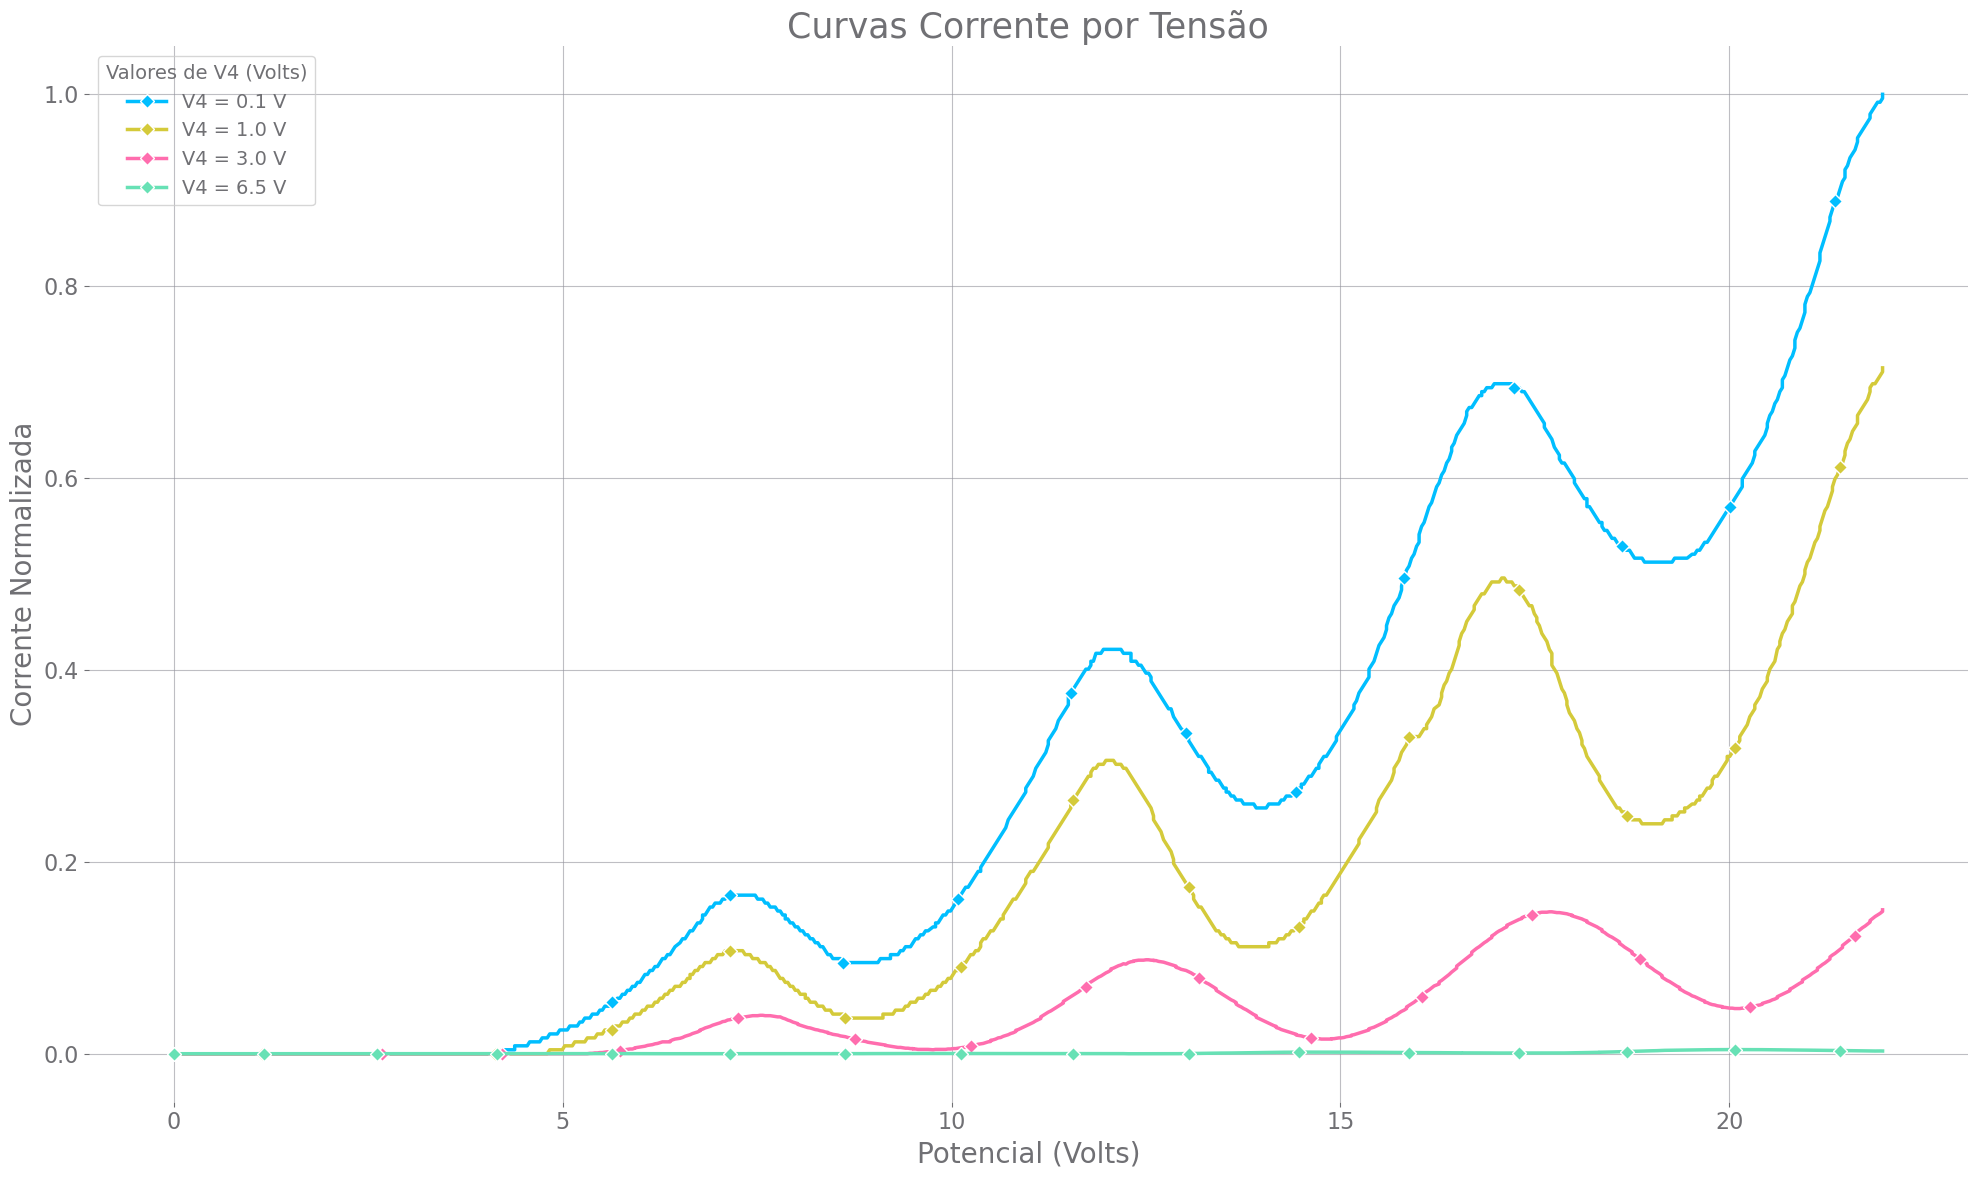

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# Caminhos fornecidos
caminho_v4 = "Medidas Multiplas Excitações 150°C (Com fator de escala).xlsx"
caminho_v4_dados = "Dados experimentais 23.10.2025 (Com fator de escala)/"

# Lê o arquivo principal (com fatores de escala)
df_v4 = pd.read_excel(caminho_v4)
display(df_v4.head())

# Limite de potencial
limite_potencial = 22

# Lista para armazenar as medidas
dados_medidas = []

for medida in range(9, 13):
    nome_arquivo = f"m{medida}-m-e-T_150.txt"
    caminho_arquivo = os.path.join(caminho_v4_dados, nome_arquivo)

    # Lê o arquivo de dados
    df_dados = pd.read_csv(
        caminho_arquivo,
        sep=r"\s+",
        header=None,
        names=["Potencial (V)", "Corrente (uA)"]
    )

    # Fator de escala e valor de V4
    linha_info = df_v4.loc[df_v4["Medida"] == medida]
    escala = linha_info["Escala "].values[0]
    v4_valor = linha_info["V4 [Volts]"].values[0]

    # Aplica o fator de escala
    df_dados["Corrente (uA)"] *= escala

    # Filtra até o limite de potencial
    df_dados = df_dados[df_dados["Potencial (V)"] <= limite_potencial].reset_index(drop=True)

    # Armazena a medida junto com o valor de V4
    dados_medidas.append((v4_valor, df_dados))

# Calcula min e max globais (correntes filtradas)
todas_correntes = np.concatenate([df["Corrente (uA)"].values for _, df in dados_medidas])
I_min, I_max = todas_correntes.min(), todas_correntes.max()

print(f"Mínimo global: {I_min:.9f}, Máximo global: {I_max:.9f}")

# Gráfico normalizado — com as mesmas características visuais do primeiro código

for v4_valor, df_dados in dados_medidas:
    df_dados["Corrente Normalizada"] = (df_dados["Corrente (uA)"] - I_min) / (I_max - I_min)
    plt.plot(
        df_dados["Potencial (V)"],
        df_dados["Corrente Normalizada"],
        label=f"V4 = {v4_valor:.1f} V",
        marker="D",
        markevery=50
    )

# Configurações do gráfico — idênticas ao primeiro
plt.xlabel("Potencial (Volts)")
plt.ylabel("Corrente Normalizada")
plt.title("Curvas Corrente por Tensão")
plt.legend(title="Valores de V4 (Volts)")
plt.grid(True)
plt.tight_layout()
plt.show()


## Gráficos em Log

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# Caminhos fornecidos
caminho_v1 = "/content/drive/MyDrive/Experimento Franck-Hertz/Medidas Multiplas Excitações 150°C (Com fator de escala) - Sheet1.csv"
caminho_v1_dados = "/content/drive/MyDrive/Experimento Franck-Hertz/Dados experimentais 23.10.2025 (Com fator de escala)/"

# Lê o arquivo principal (com fatores de escala)
df_v1 = pd.read_csv(caminho_v1)
display(df_v1.head())

# Limite de potencial
limite_potencial = 22

# Lista para armazenar as medidas
dados_medidas = []

for medida in range(9, 13):
    nome_arquivo = f"m{medida}-m-e-T_150.txt"
    caminho_arquivo = os.path.join(caminho_v1_dados, nome_arquivo)

    # Lê o arquivo de dados
    df_dados = pd.read_csv(caminho_arquivo, sep="\s+", header=None, names=["Potencial (V)", "Corrente (uA)"])

    # Fator de escala e valor de V4
    linha_info = df_v1.loc[df_v1["Medida"] == medida]
    escala = linha_info["Escala "].values[0]
    v4_valor = linha_info["V4 [Volts]"].values[0]

    # Aplica o fator de escala
    df_dados["Corrente (uA)"] *= escala

    # Filtra até o limite de potencial
    df_dados = df_dados[df_dados["Potencial (V)"] <= limite_potencial].reset_index(drop=True)

    # Armazena a medida junto com o valor de V4
    dados_medidas.append((v4_valor, df_dados))

# Calcula min e max globais (correntes filtradas)
todas_correntes = np.concatenate([df["Corrente (uA)"].values for _, df in dados_medidas])
I_min, I_max = todas_correntes.min(), todas_correntes.max()

print(f"Mínimo global: {I_min:.9f}, Máximo global: {I_max:.9f}")

# Gráfico normalizado (com log seguro)
plt.figure(figsize=(8,6))

for v4_valor, df_dados in dados_medidas:
    # Normaliza entre 0 e 1
    df_dados["Corrente Normalizada"] = (df_dados["Corrente (uA)"] - I_min) / (I_max - I_min)
    # Aplica log(1 + x) para permitir escala logarítmica
    df_dados["Corrente Log"] = np.log1p(df_dados["Corrente Normalizada"])

    plt.plot(df_dados["Potencial (V)"], df_dados["Corrente Log"],
             label=f"V4 = {v4_valor:.1f} V", marker="D", markevery=50)

# Configurações do gráfico
plt.xlabel("Potencial (V)")
plt.ylabel("log(1 + Corrente Normalizada)")
plt.title(f"Curvas de Tensão × Corrente (escala log no eixo y, até {limite_potencial} V)")
plt.legend(title="Valores de V4 [Volts]")
plt.grid(True, which="both")
plt.yscale("log")  # Escala logarítmica no eixo Y
plt.tight_layout()
plt.show()


# Vou comparar os dados obitidos para diferentes temperatuas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# Caminhos fornecidos
caminho_v1 = "/content/drive/MyDrive/Experimento Franck-Hertz/Medidas Multiplas Excitações 150°C (Com fator de escala) - Sheet1.csv"
caminho_v1_dados = "/content/drive/MyDrive/Experimento Franck-Hertz/Dados experimentais 23.10.2025 (Com fator de escala)/"

# Lê o arquivo principal (com fatores de escala)
df_v1 = pd.read_csv(caminho_v1)
display(df_v1.head())

# Limite de potencial
limite_potencial = 30

# Faixas de medidas
faixas = {
    "V1": range(1, 5),
    "V2": range(5, 9),
    "V4": range(9, 13)
}

# Temperaturas disponíveis
temperaturas = [130, 140, 150, 160]

# Função para ler e escalar uma medida
def ler_medida(medida, temperatura):
    nome_arquivo = f"m{medida}-m-e-T_{temperatura}.txt"
    caminho_arquivo = os.path.join(caminho_v1_dados, nome_arquivo)

    if not os.path.exists(caminho_arquivo):
        print(f"Aviso: arquivo {nome_arquivo} não encontrado.")
        return None

    df_dados = pd.read_csv(caminho_arquivo, sep=r"\s+", header=None, names=["Potencial (V)", "Corrente (uA)"])
    linha_info = df_v1.loc[df_v1["Medida"] == medida]

    if linha_info.empty:
        print(f"Aviso: Medida {medida} não encontrada no CSV principal.")
        return None

    escala = linha_info["Escala "].values[0]
    df_dados["Corrente (uA)"] *= escala
    df_dados = df_dados[df_dados["Potencial (V)"] <= limite_potencial].reset_index(drop=True)
    return df_dados

# Função para gerar gráfico de comparação entre temperaturas para uma medida
def plot_comparacao_medida(medida, ax=None):
    dados_temp = []
    for T in temperaturas:
        df = ler_medida(medida, T)
        if df is not None:
            dados_temp.append((T, df))

    if not dados_temp:
        return None

    # Normalização global por medida
    todas_correntes = np.concatenate([df["Corrente (uA)"].values for _, df in dados_temp])
    I_min, I_max = todas_correntes.min(), todas_correntes.max()

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    for T, df in dados_temp:
        df["Corrente Normalizada"] = (df["Corrente (uA)"] - I_min) / (I_max - I_min)
        ax.plot(df["Potencial (V)"], df["Corrente Normalizada"], label=f"T = {T}°C", marker="D", markevery=50)

    ax.set_xlabel("Potencial (V)")
    ax.set_ylabel("Corrente Normalizada")
    ax.set_title(f"Comparação das curvas da medida m{medida}")
    ax.legend(title="Temperatura")
    ax.grid(True)

    return ax

# ---- 1) Gráficos individuais para cada grupo ----
for nome, medidas in faixas.items():
    fig, axs = plt.subplots(len(medidas), 1, figsize=(8, 6 * len(medidas)))
    if len(medidas) == 1:
        axs = [axs]  # caso haja apenas um subplot
    for ax, medida in zip(axs, medidas):
        plot_comparacao_medida(medida, ax=ax)
    fig.suptitle(f"Grupo de medidas variando {nome}", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# ---- 2) Figura com múltiplos plots na horizontal (um por grupo) ----
fig, axs = plt.subplots(1, 3, figsize=(22, 6), sharey=True)

for i, (nome, medidas) in enumerate(faixas.items()):
    # Vamos representar apenas uma medida representativa por grupo (por ex. m1, m5, m9)
    medida_ref = medidas.start
    plot_comparacao_medida(medida_ref, ax=axs[i])
    axs[i].set_title(f"Variação de {nome} (m{medida_ref})")

fig.suptitle("Comparação das medidas representativas por grupo", fontsize=18)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
